<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/INTERNSHIP-DL/blob/main/hinge_alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from keras.models import Model
from keras.layers import Input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

In [ ]:
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


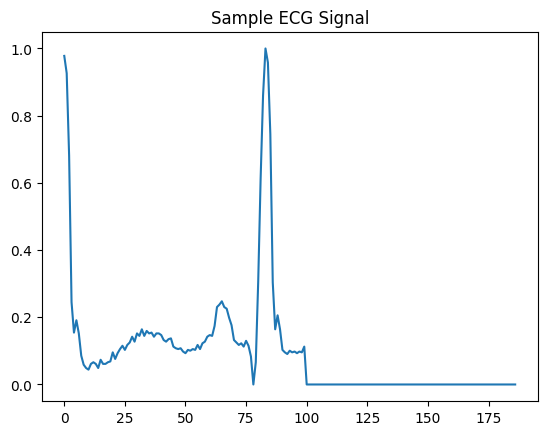

In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

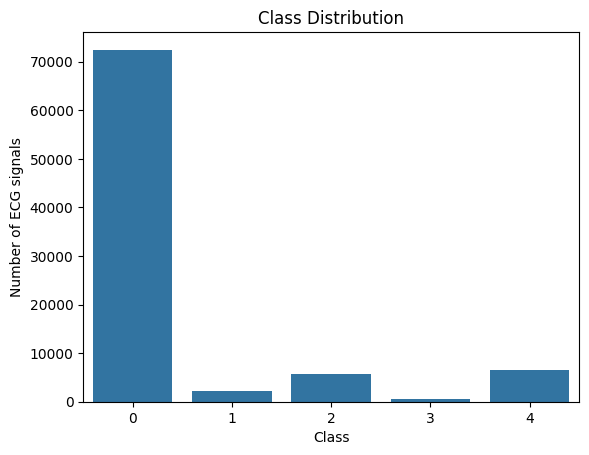

In [ ]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [ ]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [ ]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
X_res = X_res[:120000]
y_res = y_res[:120000]

In [ ]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [ ]:
def alexnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)

    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
    optimizer='adam',
    loss='hinge',
    metrics=['accuracy']
)

    return model

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr = to_categorical(y_res[train_idx], 5)
    y_va = to_categorical(y_res[val_idx], 5)

    model = alexnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 482ms/step - accuracy: 0.6030 - loss: 0.9592
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 318s 476ms/step - accuracy: 0.6039 - loss: 0.9584
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 295s 472ms/step - accuracy: 0.6039 - loss: 0.9584
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 296s 474ms/step - accuracy: 0.6039 - loss: 0.9584
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 474ms/step - accuracy: 0.6039 - loss: 0.9584
Fold 1 Accuracy: 0.6039

Fold 2
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 301s 475ms/step - accuracy: 0.6034 - loss: 0.9593
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 294s 471ms/step - accuracy: 0.6039 - loss: 0.9584
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 327s 478ms/step - accuracy: 0.6039 - loss: 0.9584
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 491ms/step - accuracy: 0.6039 - loss: 0.9584
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 474ms/step - accuracy: 0.6039 - loss: 0.9584
Fold 2 Accuracy: 0.6039

Fold 3
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
model = alexnet_ecg()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 392s 516ms/step - accuracy: 0.6011 - loss: 0.9600 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 368s 491ms/step - accuracy: 0.6015 - loss: 0.9594 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 370s 493ms/step - accuracy: 0.6015 - loss: 0.9594 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 381s 492ms/step - accuracy: 0.6015 - loss: 0.9594 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 376s 501ms/step - accuracy: 0.6015 - loss: 0.9594 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 375s 501ms/step - accuracy: 0.6015 - loss: 0.9594 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 376s 502ms/step - accuracy: 0.6015 - loss: 0.9594 - val_accuracy: 0.6135 - val_loss: 0.9546
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 381s 501ms/step - accuracy: 0.6015 -

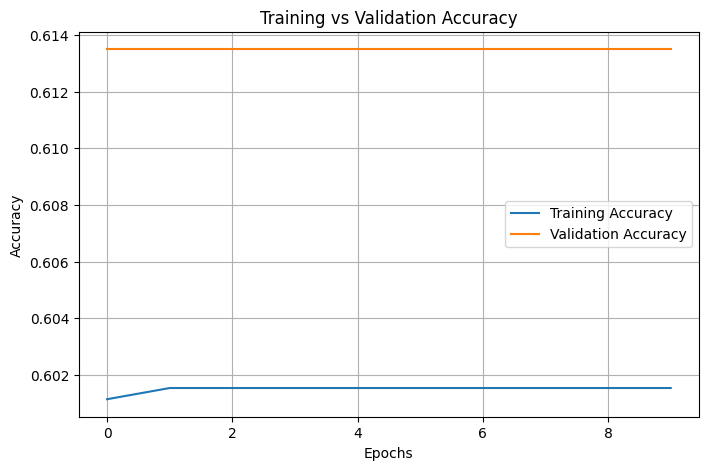

Final Training Accuracy: 0.6015
Final Validation Accuracy: 0.6135


In [ ]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [ ]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step
Validation MCC: 0.0


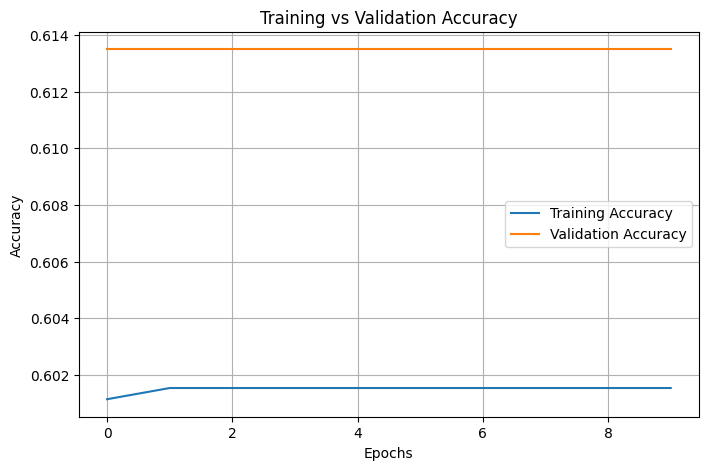

Final Training Accuracy: 0.6015
Final Validation Accuracy: 0.6135


In [ ]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

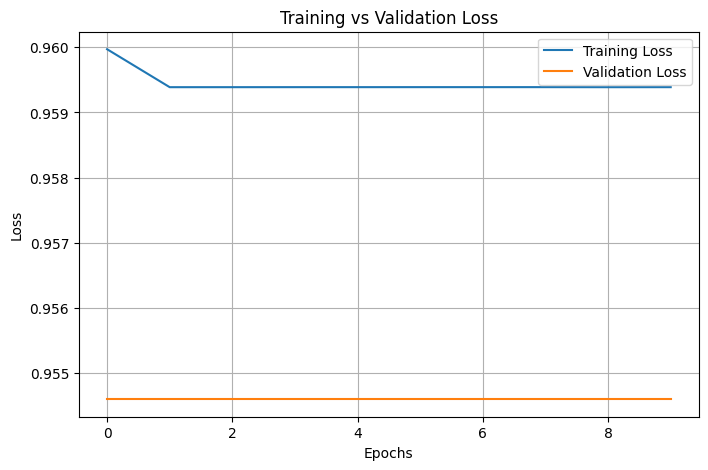

Final Training Loss: 0.9594
Final Validation Loss: 0.9546


In [ ]:
# Cell 25: Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.8690
Test Accuracy: 0.8276


In [ ]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91     18118
         1.0       0.00      0.00      0.00       556
         2.0       0.00      0.00      0.00      1448
         3.0       0.00      0.00      0.00       162
         4.0       0.00      0.00      0.00      1608

    accuracy                           0.83     21892
   macro avg       0.17      0.20      0.18     21892
weighted avg       0.68      0.83      0.75     21892



In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
num_classes = cm.shape[0]

# Lists
precision = []
recall = []
f1 = []
specificity = []
support = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1_score = (2 * prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)
    specificity.append(spec)
    support.append(np.sum(cm[i, :]))

# Convert to numpy
precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)
specificity = np.array(specificity)
support = np.array(support)

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Macro Average
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_spec = np.mean(specificity)

# Weighted Average
weights = support / np.sum(support)

weighted_precision = np.sum(precision * weights)
weighted_recall = np.sum(recall * weights)
weighted_f1 = np.sum(f1 * weights)
weighted_spec = np.sum(specificity * weights)

# Create DataFrame
report_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "specificity": specificity,
    "support": support
})

report_df.index = [f"Class {i}" for i in range(num_classes)]

# Add summary rows
summary_df = pd.DataFrame({
    "precision": [accuracy, macro_precision, weighted_precision],
    "recall":    [accuracy, macro_recall, weighted_recall],
    "f1-score":  [accuracy, macro_f1, weighted_f1],
    "specificity": [np.nan, macro_spec, weighted_spec],
    "support":   [np.sum(support), np.sum(support), np.sum(support)]
}, index=["accuracy", "macro avg", "weighted avg"])

# Combine
final_df = pd.concat([report_df, summary_df])

# Print
print(final_df.round(3))

685/685 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step
              precision  recall  f1-score  specificity  support
Class 0           0.828   1.000     0.906        0.000    18118
Class 1           0.000   0.000     0.000        1.000      556
Class 2           0.000   0.000     0.000        1.000     1448
Class 3           0.000   0.000     0.000        1.000      162
Class 4           0.000   0.000     0.000        1.000     1608
accuracy          0.828   0.828     0.828          NaN    21892
macro avg         0.166   0.200     0.181        0.800    21892
weighted avg      0.685   0.828     0.750        0.172    21892


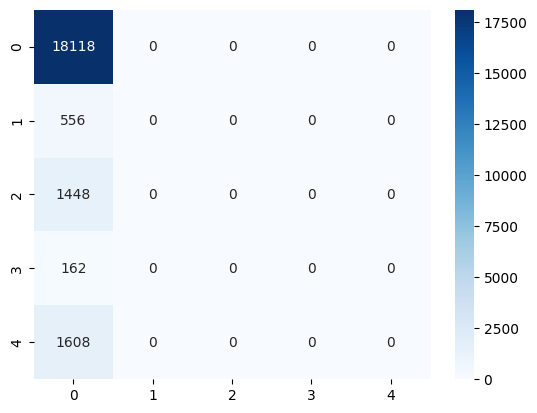

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()